In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from scipy import integrate
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import Read_PDB

This notebook was used for simulating small angle scattering curve of a protein crystal described in "Bond-centric modular design of protein assemblies" (https://doi.org/10.1101/2024.10.11.617872)

## Load the Coordinates of the Protein Crystal
The struture of the protein crystal is visualized in a 2D plot.

Text(0, 0.5, 'y axis [$\\AA$]')

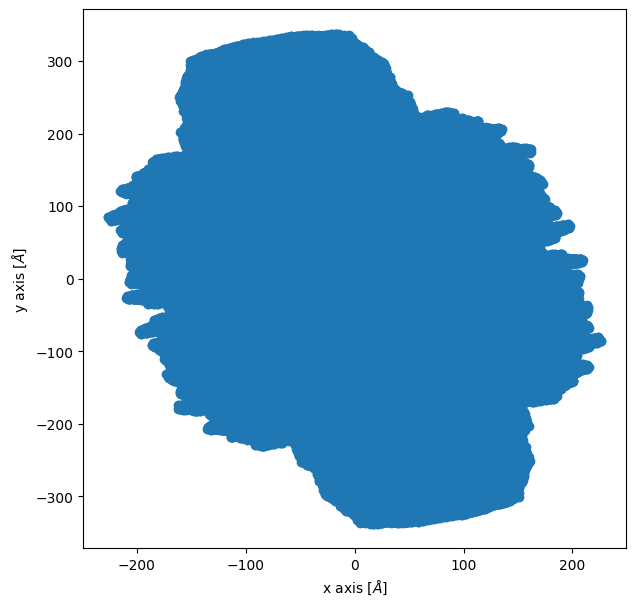

In [4]:
coordinates = Read_PDB.load_pdb('../Data/PDB/2qzv.pdb') 
fig, ax = plt.subplots(figsize=(7,7))
plt.scatter(coordinates[:,0], coordinates[:,2])
plt.xlabel('x axis [$\\AA$]')
plt.ylabel('y axis [$\\AA$]')

## Sample from the Building Block
This performs the simulation of the structure to the scattering curve using the MC-DFM.  

In [67]:
n_samples = 1000 #number of pairwise distances to create the pairwise distribution
simulator = pairwise_method.scattering_simulator(n_samples)
simulator.sample_building_block(coordinates) 
simulator.use_building_block_as_structure()

In [68]:
histogram_bins = 100000 #number of points in the pairwise distribution
q = np.geomspace(0.003, 0.15, 6000) #The q-range of the simulated scattering curve 
I_q_1e3 = simulator.simulate_scattering_curve_fast(coordinates, histogram_bins, q, save=True)

## Plot the Results
The results of the simulation is compared to experimental data. The experimental SAXS scattering curves correspond to protein crystals at different concentrations of  monodentate modulators.

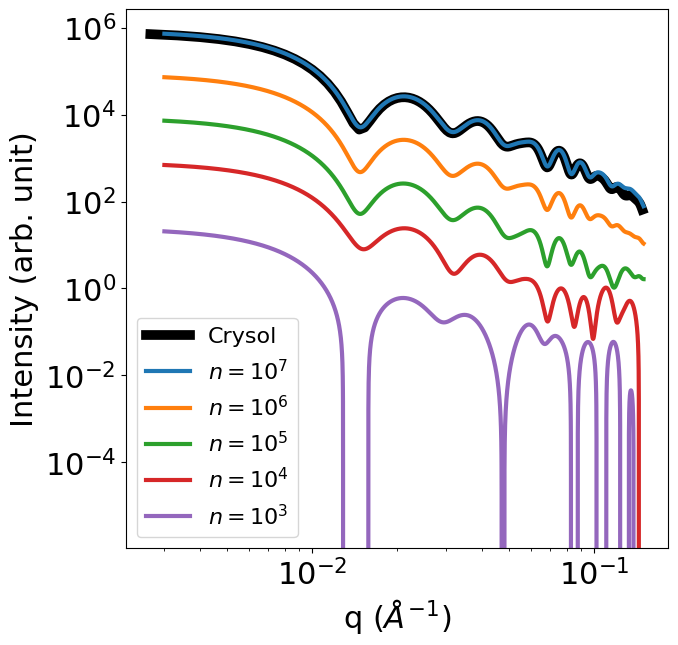

In [115]:
crysol3 = np.loadtxt('../Data/PDB/Comparison/CRYSOL_scattering_PDB_txt_2qzv.txt', skiprows=1)[3:-77,:] 

plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7))
plt.plot(crysol3[:,0], crysol3[:,1]*1.6e-6, linewidth = 7, label = 'Crysol', color='k')
plt.plot(q, I_q_1e7, linewidth = 3, label = '$n = 10^{7}$')
plt.plot(q, I_q_1e6, linewidth = 3, label = '$n = 10^{6}$')
plt.plot(q, I_q_1e5, linewidth = 3, label = '$n = 10^{5}$')
plt.plot(q, I_q_1e4, linewidth = 3, label = '$n = 10^{4}$')
plt.plot(q, I_q_1e3*0.3, linewidth = 3, label = '$n = 10^{3}$')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Intensity (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')
ax.minorticks_on()
#plt.xlim([0.003, .2])
#plt.ylim([1e-10, 1e1])

plt.legend(fontsize=16)
#plt.savefig('../Images/Effect_of_Sample_Size_2qzv.png', dpi=600, bbox_inches="tight")
plt.show()